In [1]:
import matplotlib.pyplot as plt

from segmentation_project.data.loader import ImageLoader

from segmentation_project.preprocessing.preprocessing import (Resize,Grayscale,)

from segmentation_project.ground_truth.overlay import (BinarizeMask,Overlay,)


In [8]:
# Initialize loader
loader = ImageLoader()

# List dataset images
image_paths = loader.list_images()

# Select image index
index = 2

# Selected image path
image_path = image_paths[index]

In [9]:
# Load original image
image = loader.load_image(image_path)

print("Loaded image:")
print(image_path.name)
print("Shape:", image.shape)

Loaded image:
img_2270.jpg
Shape: (1080, 1920, 3)


In [10]:
# Resize image
resized = Resize.apply(image)

# Convert to grayscale
gray = Grayscale.apply(resized)

print("Preprocessed image shape:")
print(gray.shape)

Preprocessed image shape:
(1070, 1910)


In [11]:
# Find corresponding manual mask
mask_path = loader.get_mask_path(image_path)

# Load mask
mask = loader.load_mask(mask_path)

print("Loaded mask:")
print(mask_path.name)
print("Mask shape:", mask.shape)

Loaded mask:
img_2270_mask_final.tif
Mask shape: (1070, 1910, 1)


In [12]:
# Binarize manual mask
binary_mask = BinarizeMask.apply(mask)

# Create overlay
overlay = Overlay.apply(gray, binary_mask)

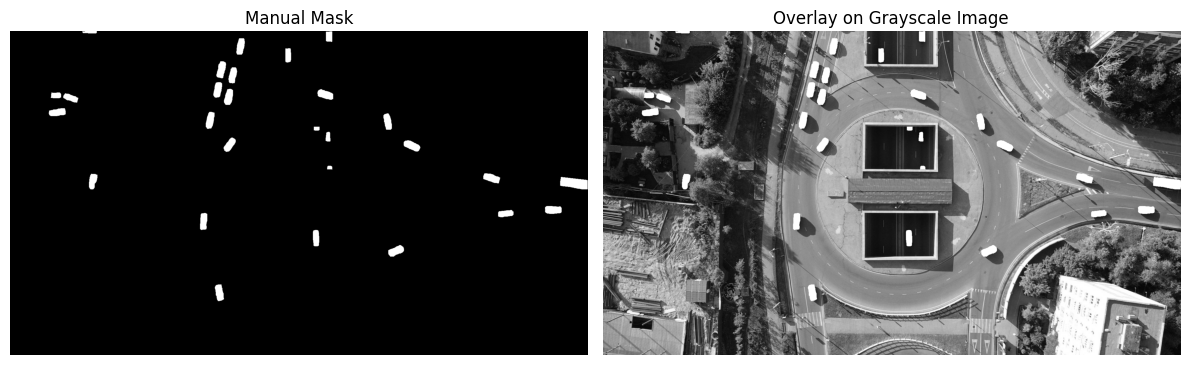

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(binary_mask, cmap="gray")
axes[0].set_title("Manual Mask")
axes[0].axis("off")

axes[1].imshow(overlay, cmap="gray")
axes[1].set_title("Overlay on Grayscale Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()